Device    : cuda:1
Baselines : ['ATC', 'ATC-NE', 'AC', 'DOC', 'COT']

LOADING TRAINING DATA


/tmp/ipykernel_132029/1333885915.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data     = torch.load(PATH_DATA)


Train scores shape: (3394245, 5)
  Class 0: 1000000 samples
  Class 1: 1000000 samples
  Class 2: 776366 samples
  Class 3: 568007 samples
  Class 4: 49872 samples

FLOW MODEL
✓ ScoreShiftFlow defined — single flow over full score vector
✓ Flow loaded from BCSS/bcss_score_shift_flow_new.pth

SCORE DISTRIBUTIONS (первый тайл)
Тайл: TCGA-EW-A3U0-DX1_xmin113512_ymin48566_MPP-0.2500.png.tensor


/tmp/ipykernel_132029/1333885915.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  flow.load_state_dict(torch.load(FLOWS_PATH, map_location=DEVICE))



------------------------------------------------------------
DEBUG: RAW ARRAYS
------------------------------------------------------------
ms shape       : (918480, 5)
ds_flow shape  : (918480, 5)
labels shape   : (918480,)

Score stats (raw logits)
ms      min/max/mean/std: -60.88426 15.173005 -0.31061265 2.0954823
ds_flow min/max/mean/std: -874.81464 256.35315 -2.545009 27.1858

Per-sample max score stats
max(ms)      min/max/mean: 0.26039135 15.173005 2.1209533
max(ds_flow) min/max/mean: -4.2438726 256.35315 11.410943

Class balance in tile:
  class 0: 225178
  class 1: 570792
  class 2: 0
  class 3: 106826
  class 4: 15684

After subsample:
n samples: 91848


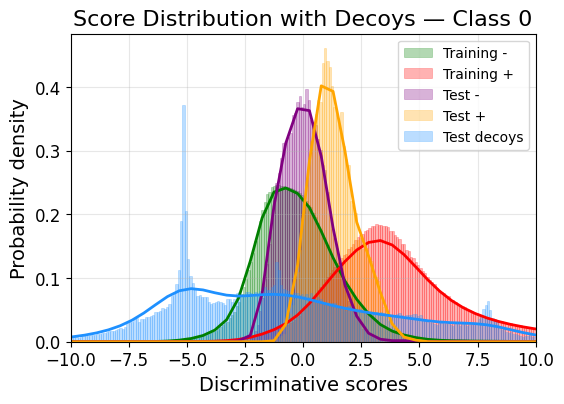

<Figure size 640x480 with 0 Axes>

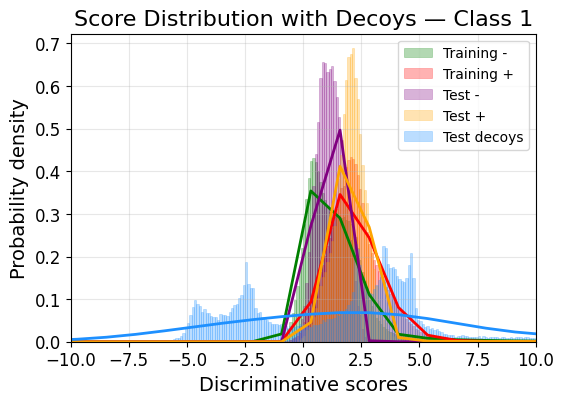

/home/arina/.conda/envs/breeds/lib/python3.9/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


<Figure size 640x480 with 0 Axes>

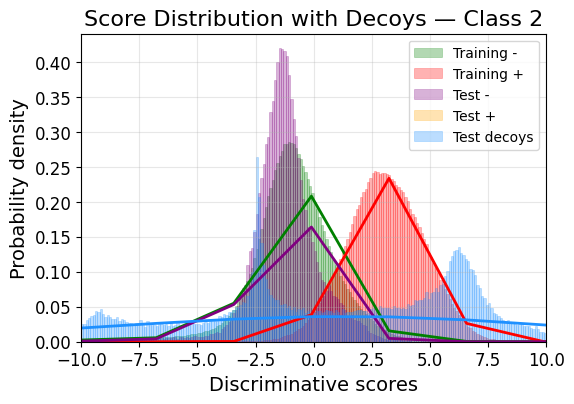

<Figure size 640x480 with 0 Axes>

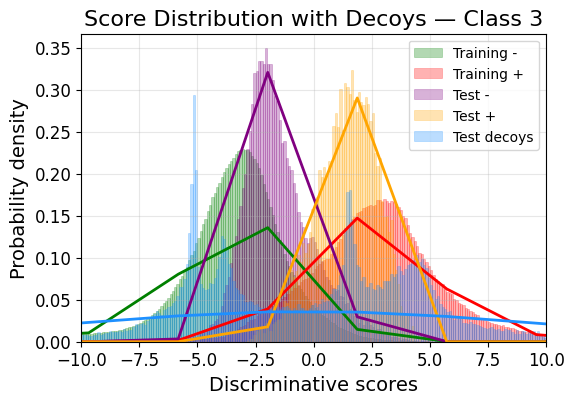

<Figure size 640x480 with 0 Axes>

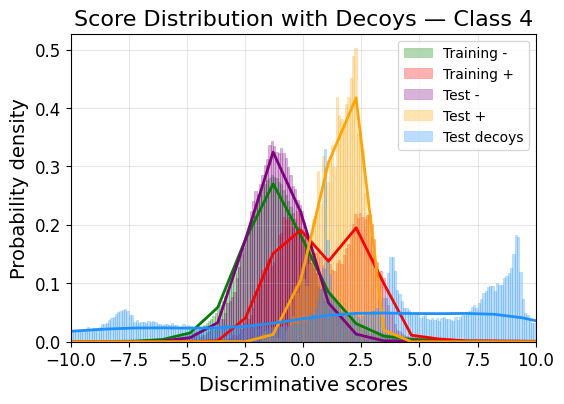

✓ Score distributions сохранены для 5 классов

DEBUG: SCORE COMPARISON
pred_scores min/max/mean: 0.33118466 13.8500395 2.106068
decoy_scores min/max/mean: -2.6961758 213.85698 11.337552
Fraction target > decoy: 0.029243968295444647
  accuracy : 0.6954
  error/pi0: 0.3046


<Figure size 640x480 with 0 Axes>

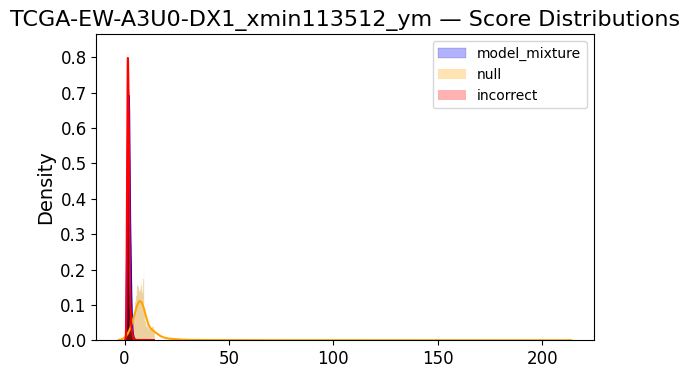

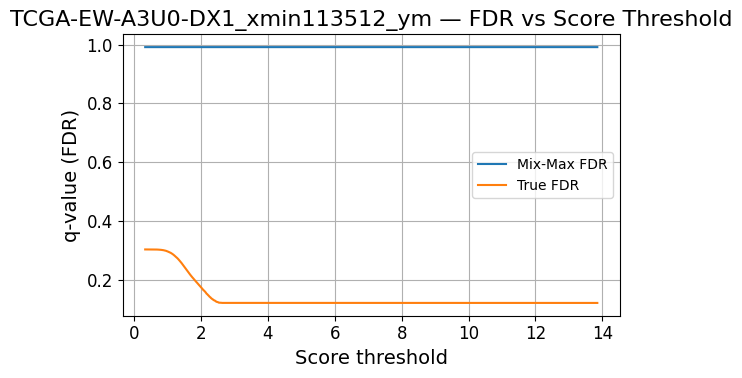

pi0_tdc 33.195085629188384
pi0_mm 0.9913457405858351

DEBUG: TRUE FDR
FDR_true min/max: 0.12304305283757339 1.0
QVAL_true min/max: 0.12304305283757339 0.3046228551519902

DEBUG: TDC
TDC_FDR min/max: 1.0 14364.0
QVAL_TDC min/max: 1.0 33.195085629188384
Any QVAL_TDC <0 ? False
Any QVAL_TDC >1 ? True


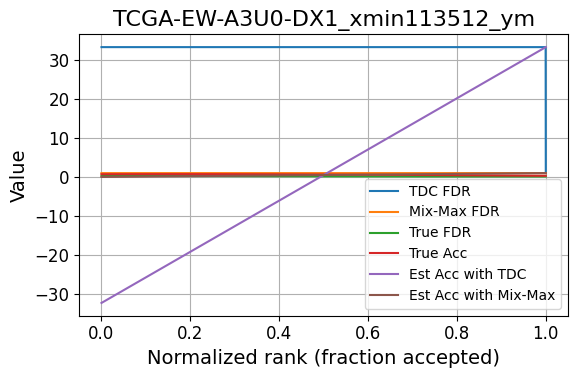


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.6954      0.7261
  TDC  (est | err)             -32.1951  +32.8905  33.1951  +32.4690
  Mix-Max (est | err)          0.0087  +0.6867  0.9913  +0.2653

✓ Debug arrays saved to BCSS/figures/diagnostics/debug_shift_flow_TCGA-EW-A3U0-DX1_xmin113512_ymin48566_MPP-0.2500.png.npz


In [3]:
import torch
from torch.utils.data import DataLoader, Subset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import glob

from data_processing.score_feature_dataset import (
    ScoreFeatureDataset,
    create_score_feature_dataset_bcss,
)
from data_processing.negative_scores_pool import collect_negative_scores
from flows.shift_flow import ScoreShiftFlowWrapper
from utils.other_methods import *
from utils.visualize_distributions import *
from fdr.fdr_control import *
from fdr.plot_fdr import *

try:
    from utils.other_methods import predict_COT
    COT_AVAILABLE = True
except ImportError:
    COT_AVAILABLE = False

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE         = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES    = 5
FEATURE_DIM    = 64
PATH_DATA      = '../../data/BCSS/training/bcss.mini.training.torch'
TEST_FOLDER    = '../../data/BCSS/test/'
FLOWS_PATH     = 'BCSS/bcss_score_shift_flow_new.pth'
SUBSAMPLE_STEP = 10
MIN_PIXELS     = 50        # минимум пикселей чтобы считать threshold-accuracy

os.makedirs('BCSS/figures/accuracy',    exist_ok=True)
os.makedirs('BCSS/figures/diagnostics', exist_ok=True)
os.makedirs('BCSS/figures/comparison',  exist_ok=True)

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 10, 'figure.titlesize': 18,
})

BASELINE_METHODS = {
    'ATC'   : predict_ATC_maxconf,
    'ATC-NE': predict_ATC_negent,
    'AC'    : predict_AC,
    'DOC'   : predict_DOC,
}
if COT_AVAILABLE:
    BASELINE_METHODS['COT'] = predict_COT

COLORS = {
    'Mix-Max': '#E53935',
    'ATC'    : '#1976D2',
    'ATC-NE' : '#0288D1',
    'AC'     : '#388E3C',
    'DOC'    : '#7B1FA2',
    'COT'    : '#F57C00',
}

print(f"Device    : {DEVICE}")
print(f"Baselines : {list(BASELINE_METHODS.keys())}")


# ============================================================================
# HELPERS
# ============================================================================

def get_scores_from_ds(dataset):
    """Вытащить scores и labels из ScoreFeatureDataset."""
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    cnn_list, lbl_list = [], []
    with torch.no_grad():
        for cnn_scores, features, target_decoy, labels in loader:
            cnn_list.append(cnn_scores.cpu().numpy())
            lbl_list.append(labels.cpu().numpy())
    return np.concatenate(cnn_list), np.concatenate(lbl_list)


def load_bcss_test_file(fpath):
    """Загрузить один .tensor тайл → ScoreFeatureDataset."""
    data        = torch.load(fpath, weights_only=False)
    predictions = torch.flatten(data['predictions'], start_dim=2).squeeze(0).T
    features    = torch.flatten(data['features'],    start_dim=2).squeeze(0).T
    labels      = torch.flatten(torch.tensor(data['mask']), start_dim=0)
    labels      = torch.where(labels <= 3, labels, torch.tensor(4))
    return ScoreFeatureDataset(predictions, features, predictions, labels)


print("\n" + "="*70)
print("LOADING TRAINING DATA")
print("="*70)

data     = torch.load(PATH_DATA)
train_ds = create_score_feature_dataset_bcss(data, DEVICE)
train_scores, train_labels = get_scores_from_ds(train_ds)
print(f"Train scores shape: {train_scores.shape}")
for c in range(NUM_CLASSES):
    print(f"  Class {c}: {(train_labels == c).sum()} samples")

print("\n" + "="*70)
print("FLOW MODEL")
print("="*70)

flow = ScoreShiftFlowWrapper(
    num_classes=NUM_CLASSES,
    n_flows=12,
    feature_dim=FEATURE_DIM,
    hidden_dim=256,
    encoder_dim=128,
).to(DEVICE)

if os.path.exists(FLOWS_PATH):
    flow.load_state_dict(torch.load(FLOWS_PATH, map_location=DEVICE))
    print(f"✓ Flow loaded from {FLOWS_PATH}")
else:
    print("Training ScoreShiftFlow...")
    flow.train_flow(
        train_ds, epochs=30, lr=3e-4, batch_size=256,
        device=DEVICE, patience=5, grad_clip=1.0)
    torch.save(flow.state_dict(), FLOWS_PATH)
    print(f"✓ Flow saved to {FLOWS_PATH}")


# ============================================================================
# PLOT 5: Score distributions для первого тайла
# ============================================================================

print("\n" + "="*70)
print("SCORE DISTRIBUTIONS (первый тайл)")
print("="*70)

test_files = sorted(glob.glob(os.path.join(TEST_FOLDER, '*.tensor')))

first_tile = TEST_FOLDER+'TCGA-EW-A3U0-DX1_xmin113512_ymin48566_MPP-0.2500.png.tensor'
tile_name  = os.path.basename(first_tile)
print(f"Тайл: {tile_name}")

try:
    test_ds_dist = load_bcss_test_file(first_tile)

    ms, ds_flow, ls = flow.generate_decoys(test_ds_dist, device=DEVICE)

    print("\n" + "-"*60)
    print("DEBUG: RAW ARRAYS")
    print("-"*60)
    print("ms shape       :", ms.shape)
    print("ds_flow shape  :", ds_flow.shape)
    print("labels shape   :", ls.shape)

    print("\nScore stats (raw logits)")
    print("ms      min/max/mean/std:",
        ms.min(), ms.max(), ms.mean(), ms.std())
    print("ds_flow min/max/mean/std:",
        ds_flow.min(), ds_flow.max(), ds_flow.mean(), ds_flow.std())

    print("\nPer-sample max score stats")
    print("max(ms)      min/max/mean:",
        np.max(ms, axis=1).min(),
        np.max(ms, axis=1).max(),
        np.max(ms, axis=1).mean())

    print("max(ds_flow) min/max/mean:",
        np.max(ds_flow, axis=1).min(),
        np.max(ds_flow, axis=1).max(),
        np.max(ds_flow, axis=1).mean())

    print("\nClass balance in tile:")
    for c in range(NUM_CLASSES):
        print(f"  class {c}: {(ls == c).sum()}")

       # Subsample
    ms       = ms[::SUBSAMPLE_STEP]
    ds_flow  = ds_flow[::SUBSAMPLE_STEP]
    ls       = ls[::SUBSAMPLE_STEP]
    n        = len(ls)

    print("\nAfter subsample:")
    print("n samples:", n)


    # plot_score_distribution_with_decoys для каждого класса
    for i in range(NUM_CLASSES):
        plot_score_distribution_with_decoys(
            train_scores[:, i],   # train scores для класса i
            train_labels,
            ms[:, i],             # test scores для класса i
            ls,
            ds_flow[:, i],       # decoy scores для класса i
            filename  = f"BCSS/figures/diagnostics/scores_dist_class{i}",
            title     = f"Score Distribution with Decoys — Class {i}",
            xlim      = (-10, 10),
            show_kde  = True,
            class_id  = i,
        )
    print(f"✓ Score distributions сохранены для {NUM_CLASSES} классов")


    true_acc_full = float((ms.argmax(axis=1) == ls).mean())

    true_labels   = ls
    n_samples     = len(true_labels)

    pred_scores   = np.max(ms, axis=1)
    pred_label    = np.argmax(ms, axis=1)
    decoy_scores  = np.max(ds_flow, axis=1)

    print("\nDEBUG: SCORE COMPARISON")
    print("pred_scores min/max/mean:",
        pred_scores.min(), pred_scores.max(), pred_scores.mean())
    print("decoy_scores min/max/mean:",
        decoy_scores.min(), decoy_scores.max(), decoy_scores.mean())

    print("Fraction target > decoy:",
      (pred_scores > decoy_scores).mean())

    correct_pred  = (true_labels == pred_label).astype(int)

    print(f"  accuracy : {correct_pred.sum() / n_samples:.4f}")
    print(f"  error/pi0: {1 - correct_pred.sum() / n_samples:.4f}")

    # ── Figure 1: Score distributions ─────────────────────────────────────
    bin_width  = 0.05
    bins       = np.arange(pred_scores.min() - 0.5,
                           pred_scores.max() + 0.5, bin_width)
    stat       = 'density'
    plot_alpha = 0.3

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(pred_scores,
                 bins=bins, stat=stat, color='blue',   kde=True,
                 fill=True, alpha=plot_alpha, label='model_mixture', ax=ax)
    sns.histplot(decoy_scores,
                 bins=bins, stat=stat, color='orange', kde=True,
                 fill=True, alpha=plot_alpha, label='null', ax=ax)
    sns.histplot(pred_scores[true_labels != pred_label],
                 bins=bins, stat=stat, color='red',    kde=True,
                 fill=True, alpha=plot_alpha, label='incorrect', ax=ax)
    ax.set_title(f'{tile_name[:30]} — Score Distributions')
    ax.legend()
    plt.tight_layout()
    safe_name = 'shift_flow_' + tile_name.replace('.tensor', '')
    plt.savefig(f'BCSS/figures/diagnostics/{safe_name}_scores.png', dpi=150)
    plt.savefig(f'BCSS/figures/diagnostics/{safe_name}_scores.pdf')
    plt.show(); plt.close()

    # ── True FDR (ground truth) ───────────────────────────────────────────
    sort_idx           = np.argsort(pred_scores)
    pred_scores_sorted = pred_scores[sort_idx]
    label_sorted       = true_labels[sort_idx]
    pred_label_sorted  = pred_label[sort_idx]
    correct_pred_s     = (label_sorted == pred_label_sorted).astype(int)

    FD       = 1 - correct_pred_s
    FD_CF    = np.cumsum(FD[::-1])[::-1]
    D_CF     = np.arange(0, n_samples)[::-1] + 1
    FDR_true = FD_CF / D_CF
    QVAL_true = np.minimum.accumulate(FDR_true)

    # ── Mix-Max FDR ───────────────────────────────────────────────────────
    pi0 = 0.0

    sorted_decoys         = np.sort(decoy_scores)
    unique_z_vals, counts_z = np.unique(decoy_scores, return_counts=True)
    n_unique_z            = len(unique_z_vals)

    counts_w_leq_z = np.searchsorted(pred_scores_sorted, unique_z_vals, side='left')
    counts_z_leq_z = np.searchsorted(sorted_decoys,      unique_z_vals, side='left')

    P_W_leq_z = (counts_w_leq_z - pi0 * counts_z_leq_z) / ((1 - pi0) * n_samples)
    P_W_leq_z = np.clip(P_W_leq_z, 0, 1)
    P_Y_leq_z = counts_z_leq_z / n_samples

    R_j = np.divide(P_W_leq_z, P_Y_leq_z,
                    out=np.zeros_like(P_W_leq_z),
                    where=P_Y_leq_z > 0)
    R_j = np.clip(R_j, 0, 1)

    all_thresholds = pred_scores_sorted[::-1]
    fdr_values     = np.zeros(n_samples)

    for i, T in enumerate(all_thresholds):
        D     = i + 1
        F_0   = pi0 * np.sum(decoy_scores > T)
        z_idx = np.searchsorted(unique_z_vals, T, side='left')
        if z_idx >= n_unique_z:
            F_1 = 0.0
        else:
            F_1 = (1 - pi0) * np.sum(R_j[z_idx:] * counts_z[z_idx:])
        fdr_values[i] = (F_0 + F_1) / D if D > 0 else 0

    QVAL_mixmax = np.minimum.accumulate(fdr_values[::-1])

    # ── Figure 2: FDR vs score threshold ──────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(pred_scores_sorted, QVAL_mixmax, label='Mix-Max FDR')
    ax.plot(pred_scores_sorted, QVAL_true,   label='True FDR')
    ax.set_xlabel('Score threshold')
    ax.set_ylabel('q-value (FDR)')
    ax.set_title(f'{tile_name[:30]} — FDR vs Score Threshold')
    ax.legend(); ax.grid()
    plt.tight_layout()
    plt.savefig(f'BCSS/figures/diagnostics/{safe_name}_fdr_vs_score.png', dpi=150)
    plt.savefig(f'BCSS/figures/diagnostics/{safe_name}_fdr_vs_score.pdf')
    plt.show(); plt.close()

    # ── TDC FDR ───────────────────────────────────────────────────────────
    TDC       = (pred_scores > decoy_scores).astype(int)
    TDC_score = np.maximum(pred_scores, decoy_scores)

    tdc_sort_idx = np.argsort(TDC_score)
    TDC_score_s  = TDC_score[tdc_sort_idx]
    TDC_label_s  = TDC[tdc_sort_idx]

    FD_CF_tdc = np.cumsum((1 - TDC_label_s)[::-1])[::-1]
    D_CF_tdc  = np.arange(0, n_samples)[::-1] + 1 - FD_CF_tdc
    D_CF_tdc  = np.maximum(D_CF_tdc, 1)
    TDC_FDR   = FD_CF_tdc / D_CF_tdc
    QVAL_TDC  = np.minimum.accumulate(TDC_FDR)

    # ── Acc estimation ─────────────────────────────────────────────────────
    pi0_tdc = QVAL_TDC[0]
    pi0_mm  = QVAL_mixmax[0]
    print('pi0_tdc', pi0_tdc)
    print('pi0_mm', pi0_mm)

    Acc_est    = np.zeros(n_samples)
    Acc_est_MM = np.zeros(n_samples)
    Acc_true   = np.zeros(n_samples)

    for i in range(n_samples):
        TP_true     = correct_pred_s[i:].sum()
        TN_true     = (1 - correct_pred_s[:i]).sum()
        Acc_true[i] = (TP_true + TN_true) / n_samples

        accepted       = n_samples - i
        FP_tdc         = accepted * QVAL_TDC[i]
        TP_tdc         = accepted * (1 - QVAL_TDC[i])
        TN_tdc         = n_samples * pi0_tdc - FP_tdc
        Acc_est[i]     = (TP_tdc + TN_tdc) / n_samples

        FP_mm          = accepted * QVAL_mixmax[i]
        TP_mm          = accepted * (1 - QVAL_mixmax[i])
        TN_mm          = n_samples * pi0_mm - FP_mm
        Acc_est_MM[i]  = (TP_mm + TN_mm) / n_samples

    print("\nDEBUG: TRUE FDR")
    print("FDR_true min/max:", FDR_true.min(), FDR_true.max())
    print("QVAL_true min/max:", QVAL_true.min(), QVAL_true.max())

    print("\nDEBUG: TDC")
    print("TDC_FDR min/max:", TDC_FDR.min(), TDC_FDR.max())
    print("QVAL_TDC min/max:", QVAL_TDC.min(), QVAL_TDC.max())
    print("Any QVAL_TDC <0 ?", np.any(QVAL_TDC < 0))
    print("Any QVAL_TDC >1 ?", np.any(QVAL_TDC > 1))

    # ── Figure 3: Acc & FDR vs normalised rank ────────────────────────────
    normalized_rank = np.arange(n_samples) / n_samples

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(normalized_rank, QVAL_TDC,    label='TDC FDR')
    ax.plot(normalized_rank, QVAL_mixmax, label='Mix-Max FDR')
    ax.plot(normalized_rank, QVAL_true,   label='True FDR')
    ax.plot(normalized_rank, Acc_true,    label='True Acc')
    ax.plot(normalized_rank, Acc_est,     label='Est Acc with TDC')
    ax.plot(normalized_rank, Acc_est_MM,  label='Est Acc with Mix-Max')
    ax.set_xlabel('Normalized rank (fraction accepted)')
    ax.set_ylabel('Value')
    ax.set_title(f'{tile_name[:30]}')
    ax.legend(); ax.grid()
    plt.tight_layout()
    plt.savefig(f'BCSS/figures/accuracy/{safe_name}_acc_fdr.png', dpi=150)
    plt.savefig(f'BCSS/figures/accuracy/{safe_name}_acc_fdr.pdf')
    plt.show(); plt.close()

    # ── ACC_ST / ACC_TA metrics ────────────────────────────────────────────
    acc_st_true    = Acc_true[0]
    acc_ta_true    = Acc_true.max()

    acc_st_est_tdc = Acc_est[0]
    acc_ta_est_tdc = Acc_est.max()

    acc_st_est_mm  = Acc_est_MM[0]
    acc_ta_est_mm  = Acc_est_MM.max()

    err_st_tdc = abs(acc_st_est_tdc - acc_st_true)
    err_ta_tdc = abs(acc_ta_est_tdc - acc_ta_true)
    err_st_mm  = abs(acc_st_est_mm  - acc_st_true)
    err_ta_mm  = abs(acc_ta_est_mm  - acc_ta_true)



    print(f"\n  {'':28} {'ACC_ST':>10}  {'ACC_TA':>10}")
    print(f"  {'─'*52}")
    print(f"  {'True':<28} {acc_st_true:>10.4f}  {acc_ta_true:>10.4f}")
    print(f"  {'TDC  (est | err)':<28} "
          f"{acc_st_est_tdc:>6.4f}  {err_st_tdc:>+.4f}  "
          f"{acc_ta_est_tdc:>6.4f}  {err_ta_tdc:>+.4f}")
    print(f"  {'Mix-Max (est | err)':<28} "
          f"{acc_st_est_mm:>6.4f}  {err_st_mm:>+.4f}  "
          f"{acc_ta_est_mm:>6.4f}  {err_ta_mm:>+.4f}")
    
    debug_save_path = f"BCSS/figures/diagnostics/debug_{safe_name}.npz"

    np.savez_compressed(
        debug_save_path,
        ms=ms,
        ds_flow=ds_flow,
        labels=ls,
        pred_scores=pred_scores,
        decoy_scores=decoy_scores,
        QVAL_TDC=QVAL_TDC,
        QVAL_mixmax=QVAL_mixmax,
        QVAL_true=QVAL_true,
    )

    print(f"\n✓ Debug arrays saved to {debug_save_path}")

except Exception as e:
    print(f"✗ Ошибка при построении distributions: {e}")